# Adaptive, degenerat, and yet comparable? Rethinking representational comparisons

The goal of this tutorial is to bridge intuitive motivations for comparing representations with a theoretical framework for assessingwhen such comparisons are scientifically meaningful, and when they may be misleading. We will rely on (very) simple neural networks to build a clearer picture of why and when representational comparisons should, and should not, work.

Representational comparison is a methodological framework in cognitive science, neuroscience, and machine learning used to quantify the similarty between the internal activity patterns of different information-processing systems, like biologican and artificial neural networks.

Throughout this session, we use the term _neural network_ broadly to include both biological and artificial systems. Although these systems differ substantially in their implementational details and constraints, such as architecture and learning rules, we treat them as instances of the _connectionits_ idea that function emerges from parallel computations among interconnected units that generate and rely on patterns of neural activity. By analyzing these activation patterns, we aim to understand the computational strategies shared across systems.

Specifically, we will examine three common assumptions underlying representational similarity analysis:
1. **Functional equivalence implies representational alignment**: If two systems implement the same, or similar, input-output function, comparisons of neural activity are well-posed
2. **Task demands drive representational convergence**: As tasks become more difficulty and ecologically demanding, the space of admissible representations shrinks, therby promoting convergence across systems
3. **Existance of a privileged representation**: For a given task, there exists a preferable ground truth representation, and neural networks that implement it are better than others

From these intuitions, the following two conclusions are frequently derived:
1. **Data statistics determine representation**: The structure of the environment or task induce the existence of a unique, optimal, and thus comparable representation
2. **Metric adequacy resolves representational questions**: The validity of a comparison depends on the choice of metric, the right metric can accurately determine similarity

Throughout this tutorial, we will examine when these intuitions are useful and when they break down, and develop a more nuance perspective in which studying how represetnations form, differ, and support distinct computational affordances can be more informative than measuring representational (dis-)similarities.

## Two-layer linear networks

Let's begin our journey with one of the simplest possible neural networks: a two-layer linear networks. Despite their simplicity, they provide a canoncial model of mapping from inputs, to hidden activation patterns, to outputs. Where here, "inputs" may denote an external stimulus, an abstract feature vector, or upstream population activity, "hidden activation" may refer to an EEG, or fMRI measure, a neural electorde recording, or activity of an artificial neural entwork, while "outputs" may denote an action, an abstract label, or downstream neural activity.

Despite its simplicity, they will be particularly helpful for our endeavor for the following four reasons:
1. They are easy to study and understand numerically and anlytically
2. Their optimal behavior is well defined and easy to understand: linear regression
3. They have a well-defined solution manifold, which makes questions of optimality and representation learning tracktable for any given task
5. This let's us study neural comparisons independently of the learning algorithm, hyperparameters and other optimization details

If this feels abstract at first, do not worry: we will proceed step by step.

### The network function
A two-layer linear network has an input weight matrix $\mathbf{W}_1$, and an output or readout weight matrix $\mathbf{W}_2$. Given a set of $P$ inputs collected in the matrix $\mathbf{X} = [\mathbf{x}_1, \mathbf{x}_2, ..., \mathbf{x}_P]$ and corresponding target outputs $\mathbf{Y} = [\mathbf{y}_1, \mathbf{y}_2, ..., \mathbf{y}_P]$, the first layer maps inputs to hidden representations:
$$\mathbf{H} = \mathbf{W}_1\mathbf{X},$$
which are then mapped to outputs via the readout layer
$$\mathbf{\hat Y} = \mathbf{W}_2\mathbf{H}.$$
Combining the two layers, the network function becomes
$$\mathbf{\hat Y} = \mathbf{W}_2\mathbf{W}_1\mathbf{X}.$$

### The scalar linear neural network
Since this is yet still very abstract, we now move to the simplest possible case of two-layer linear networks: a network with one input neuron, one hidden neuron, and one output neuron. 

In this scalar setting, the hidden activity is $h = w_1x$, and the network output is $\hat y = w_2 h$. For a single input $x_1 = 1$, and $w_1 = 1$, and $w_2 =2$, the network output is $\hat y = w_2w_1x = 2 * 1 * 1 = 2$. We will now implement this minimal network and use it to build intuition:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def scalar_linear_network(w1, w2, x):
    y_hat = w2 * w1 * x # TODO: Implement the scalar network function
    return y_hat

w1 = 1.0
w2 = 2.0
x = 1.0
assert scalar_linear_network(w1, w2, x) == 2.0

Well that was quick and easy!

## Neural networks are degenerate
Next, we are going to derive the key insight of this tutorial: the mapping from network parameters to network function is not one-to-one. Many different parameter settings can implement exactly the same input-output map. We thus say that neural networks are degenerate or non-identifiable: the network's behavior can be fixed while its intern parameterization and - crucially - hidden representations vary.

To see this, let's consider our super simple scalar neural network. Given the input $x=1$ and and target output $y=2$, any pair of input and output weights for which
$$w_2w_1 = 2$$
is a valid solution. For example $w_1=2, w_2 =1$, $w_1=\sqrt{2}, w_2 =\sqrt{2}$, and $w_1=1, w_2 =2$ all implement the same input-output map. More generally, for any nonzero scalar $q$
$$\tilde{w}_1 = q w_1, \qquad \tilde{w}_2 = w_2\frac{1}{q}$$
produces the same input-output map because
$$\tilde{w}_2\tilde{w}_1 = w_2 \frac{1}{q} q w_1 = w_2w_1.$$

This means that the set of optimal solutions is not a single point in weight space, but a whole **solution manifold**. Let's visualize and build this intuition!

What even does weight space mean? All combinations of possible weights. Each of these weights will lead to a certain network output. Let's visualize this:

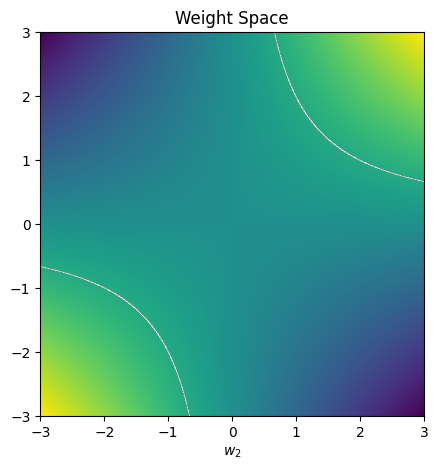

In [3]:
x = 1.0

steps = 500
vmin, vmax = -3.0, 3.0
parameter_range = np.linspace(vmin, vmax, steps)

network_outputs = np.zeros((steps, steps))

for i, w1 in enumerate(parameter_range):
    for j, w2 in enumerate(parameter_range):
        network_outputs[i, j] = scalar_linear_network(w1, w2, x) # TODO: call the scalar linear network with the current set of parameters


network_outputs[(network_outputs < 2.02) & (network_outputs > 1.98)] = None # TODO: set point in which the network output is close 1 to None

fig, ax = plt.subplots()
ax.set_title("Weight Space")
ax.imshow(network_outputs, origin="lower", extent=[vmin, vmax, vmin, vmax])
ax.set_xticks(np.linspace(vmin, vmax, 7))
ax.set_yticks(np.linspace(vmin, vmax, 7))
ax.set_xlabel("$w_1$")
ax.set_xlabel("$w_2$")
fig.tight_layout()

Here it is, the weight space! And we have marked areas in which the network is (almost) optimal! As you can see, the set of weights tgat implement a solution form two hyperbolas - this is the so called solution manifold. Next, let's be more precise on how we visualize this manifold, using the equations. We now that for any combination of $w_1$ and $w_2$ which implement a solution, for any $q$ unqual zero $\tilde{w}_1 = w_1q$ and $\tilde{w}_2 = \frac{1}{q}w_2$ implements a solution too. We can use this knowledge to neatly plot the solution manifold!

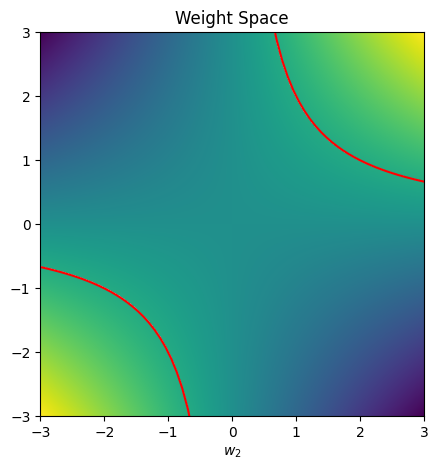

In [4]:
w1 = np.sqrt(2) # TODO: Pick a w1 and w2 that implement a solution
w2 = np.sqrt(2)

q = np.linspace(0.001, 3) # TODO: Set the appropriate range for q


fig, ax = plt.subplots()
ax.set_title("Weight Space")
ax.imshow(network_outputs, origin="lower", extent=[vmin, vmax, vmin, vmax])

ax.plot(q * w1, 1. / q * w2, c="red") # TODO: Plot w_1 * q as x and 1.0 / q * w2 as y
ax.plot(-q * w1, 1. / -q * w2, c="red") # TODO: Why does this only plot one of the hyporbolas? Plot the second one!

ax.set_xlim(vmin, vmax)
ax.set_ylim(vmin, vmax)
ax.set_xticks(np.linspace(vmin, vmax, 7))
ax.set_yticks(np.linspace(vmin, vmax, 7))
ax.set_xlabel("$w_1$")
ax.set_xlabel("$w_2$")

fig.tight_layout()

### Function and representation are dissociable

Now that we have established that there exists a whole manifold of solutions, the crucial insight is, that different solutions use different hidden layer representations while implementing the same function! In particular, the choice of $q$ transforms the hidden representation as
$$h = q w_1 x!$$

Use the following interactive figure to get an intuition of this interaction:

HTML(value='<b>x</b> = 1.00 &nbsp;&nbsp; <b>q</b> = 1.500 &nbsp;&nbsp; <b>w1</b> = 2.121 &nbsp;&nbsp; <b>w2</b…

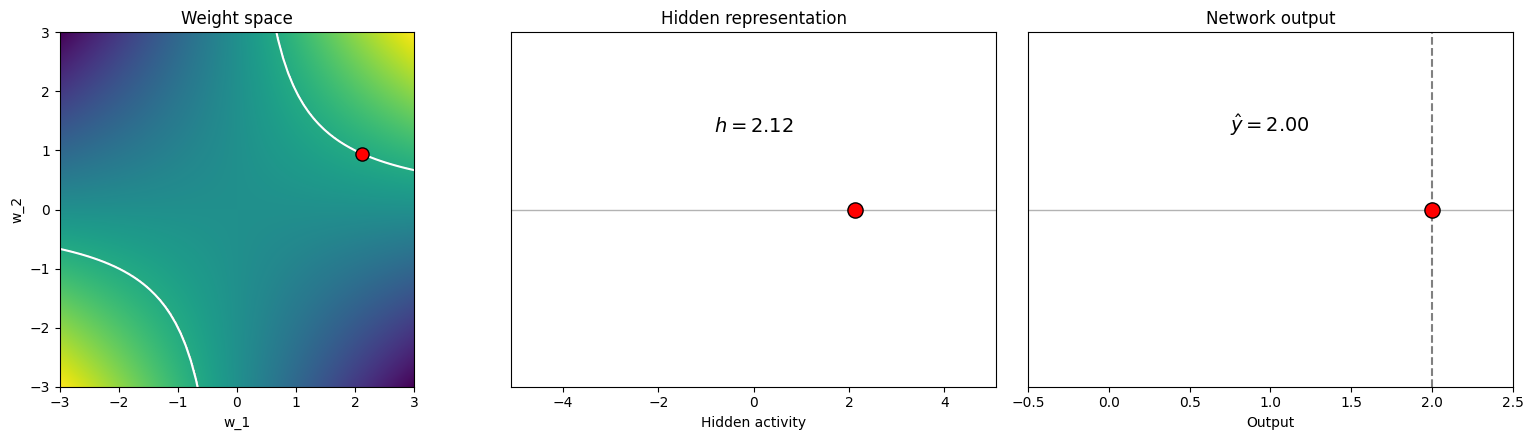

In [8]:
import ipywidgets as widgets
from IPython.display import display

s = np.sqrt(2.0 / x)
q_abs_min = max(1e-3, s / vmax)
q_abs_max = vmax / s

state = {"q_sign": 1}

q_slider = widgets.FloatSlider(
    value=np.clip(1.5, q_abs_min, q_abs_max),
    min=q_abs_min,
    max=q_abs_max,
    step=0.01,
    description="|q|",
    continuous_update=False,
    readout_format=".3f",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="420px"),
)

flip_button = widgets.Button(
    description="Flip sign of q",
    layout=widgets.Layout(width="160px"),
)

info = widgets.HTML()

fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axs[0]
ax.set_title("Weight space")
ax.imshow(network_outputs, origin="lower", extent=[vmin, vmax, vmin, vmax])
ax.plot(q * w1, 1. / q * w2, c="white")
ax.plot(-q * w1, 1. / -q * w2, c="white")

point = ax.scatter([], [], s=90, c="red", edgecolors="black", zorder=3)
ax.set_xlim(vmin, vmax)
ax.set_ylim(vmin, vmax)
ax.set_xlabel(r"w_1")
ax.set_ylabel(r"w_2")

ax = axs[1]
ax.set_title("Hidden representation")
ax.axhline(0, color="0.7", linewidth=1)
hidden_point = ax.scatter([], [], s=120, c="red", edgecolors="black", zorder=3)
hidden_text = ax.text(0.5, 0.72, "", transform=ax.transAxes, ha="center", fontsize=14)
ax.set_xlim(-max(1.0, 1.2 * vmax * s), max(1.0, 1.2 * vmax * s))
ax.set_ylim(-1, 1)
ax.set_yticks([])
ax.set_xlabel(r"Hidden activity")

ax = axs[2]
ax.set_title("Network output")
ax.axhline(0, color="0.7", linewidth=1)
ax.axvline(target_y, linestyle="--", linewidth=1.5, color="0.5")
output_point = ax.scatter([], [], s=120, c="red", edgecolors="black", zorder=3)
output_text = ax.text(0.5, 0.72, "", transform=ax.transAxes, ha="center", fontsize=14)
ax.set_xlim(-0.5, max(2.5, 1.2 * target_y))
ax.set_ylim(-1, 1)
ax.set_yticks([])
ax.set_xlabel(r"Output")

fig.tight_layout()

def update_plot(*args):
    q_mag = float(q_slider.value)
    q = state["q_sign"] * q_mag

    w1 = q * s
    w2 = (1.0 / q) * s
    h = w1 * x
    y_hat = scalar_linear_network(w1, w2, x)

    point.set_offsets(np.array([[w1, w2]]))
    hidden_point.set_offsets(np.array([[h, 0.0]]))
    output_point.set_offsets(np.array([[y_hat, 0.0]]))

    hidden_text.set_text(rf"$h = {h:.2f}$")
    output_text.set_text(rf"$\hat{{y}} = {y_hat:.2f}$")

    info.value = (
        f"<b>x</b> = {x:.2f} &nbsp;&nbsp; "
        f"<b>q</b> = {q:.3f} &nbsp;&nbsp; "
        f"<b>w1</b> = {w1:.3f} &nbsp;&nbsp; "
        f"<b>w2</b> = {w2:.3f}"
    )

    # Only request a redraw; do not call fig.canvas.draw()
    if hasattr(fig.canvas, "draw_idle"):
        fig.canvas.draw_idle()

def flip_sign(_):
    state["q_sign"] *= -1
    update_plot()

flip_button.on_click(flip_sign)
q_slider.observe(update_plot, names="value")

# Initial update
update_plot()

ui = widgets.HBox([q_slider, flip_button])
display(ui, info, fig.canvas)

### Dissociation of function and representation in higher dimensional networks

Now that we have build intuition in the simplest of all possible simple linear networks, let's increase the complexity a bit. The principle that we have investigated - that there exist many scalars $q$ for which the network input-output map stays the same, but the hidden representation changes, generalized to more complex, higher-dimensional networks.

Too see this, consider a feed-forward network with input weights $\mathbf{W}_1$ and output weights $\mathbf{W}_2$. For any invertible matrix $\mathbf{Q}$ - that is, a matrix for which $\mathbf{Q^{-1}}\mathbf{Q} = \mathbf{I}$ - we can define an equivalent parameterization
$$\mathbf{\tilde{W}}_1 = \mathbf{Q}\mathbf{W}_1, \qquad \mathbf{\tilde{W}}_2 = \mathbf{W}_2\mathbf{Q^{-1}}$$
because
$$\mathbf{\tilde{W}}_2\mathbf{\tilde{W}}_1 = \mathbf{W}_2\mathbf{Q^{-1}}\mathbf{Q}\mathbf{W}_1 = \mathbf{W}_2\mathbf{W}_1,$$
the hidden activity, however, is transformed as
$$\mathbf{\tilde{H}} = \mathbf{Q}\mathbf{W}_1\mathbf{X}!$$

Here, $\mathbf{Q}$ can do more than rescaling individual units: it can rotate, reflect, scale, shear, and mix hidden dimensions. As a result, the hidden representations of multiple inputs can be reorganized both individually as well as relative to one another. As a consequence, how different activation patterns related to each other - the so called representational geometry - does change!

In this example, we are going to use a very simple measure of representational similarity, we simply define the representational similarity matrix as the non-normalized correlation matrix
$$\begin{aligned}
\text{RSM} &= \mathbf{X}^T\mathbf{W}_1^T\mathbf{W}_1\mathbf{X}\\
&= \mathbf{H}^T\mathbf{H}
\end{aligned}$$


Let's build our intuition again, this time with a slightly more complex network with two input, two hidden, and two output neurons.

Use the following interactive figure and change the four entries of $\mathbf{Q}$, note how the hidden representation, and the representational similarity are changing, while the network output stays exaxtly fixed.

## Representational similarity analysis

We now build on the key insight from the prvious section: many distinct neural activation patterns, with diverse neural geometries, can implement the same input-output function. This raises the natural question of how such degeneracy affect representational similarity analysis?

To investigate this, we turn to a concrete task.

### The semantic hierarchy task
We define a simple task that allows us to study representational comparisons: semantic hierarchies. In such hierarchies, concpets are organized at multiple levels of abstraction, with higher-level categories subsuming more specific ones. For example, a cat is a mammal, an animal, and a living thing; an owl is a bird, an animal, and a living thing; and a rose is a flower, a plant, and a living thing. Importantly, these hierarchies naturally induce an _intuituve_ similarity structure: the closer two items are within the hierarchy, the more similar they are. For instance, a cat is more similar to an owl than to a rose.

In the following, we aim to address two questions:
1. If two neural networks implement a solution to the semantic hierarchy task, can this be inferred from comparing their internal representations?
2. Does representational similarity necessarily align with the _intuitive_ similarity structure of the task?

Formally, each input represents and object, and the target output encodes its positin within the hierarchy. Specifically, we implement inputs as distinct orthogonal vectors, and outputs as multi-hot vectors that indicate category membership at different levels of abstraction.

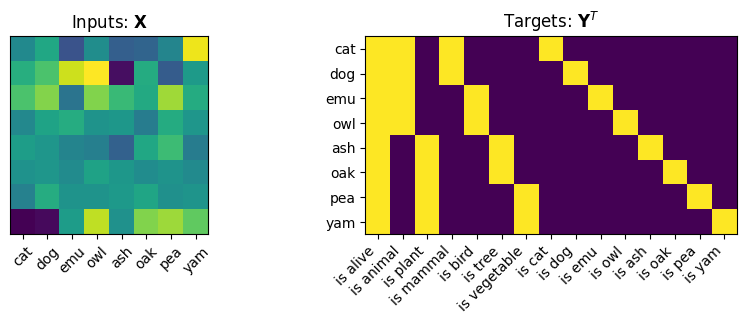

In [25]:
from scipy.stats import ortho_group

objects = ["cat", "dog", "emu", "owl", "ash", "oak", "pea", "yam"]
categories = ["alive", "animal", "plant", "mammal", "bird", "tree", "vegetable"] + objects

xs = ortho_group.rvs(dim=len(objects)) * np.random.uniform(-1.0, 1.0, (8, 1))
ys = np.asarray([
    [1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0], # cat
    [1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0], # dog
    [1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0], # emu
    [1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0], # owl
    [1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0], # ash
    [1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0], # oak
    [1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0], # pea
    [1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1], # TODO: Insert the target vector for yam
]).T

fig, axs = plt.subplots(1, 2, figsize=(9, 3))
axs[0].imshow(xs)
axs[0].set_xticks(range(len(objects)))
axs[0].set_xticklabels(objects, rotation=45)
axs[0].set_yticks([])
axs[0].set_title("Inputs: $\\mathbf{X}$")

axs[1].imshow(ys.T)
axs[1].set_xticks(range(len(categories)))
axs[1].set_xticklabels([f"is {c}" for c in categories], rotation=45, ha="right")
axs[1].set_yticks(range(len(objects)))
axs[1].set_yticklabels(objects)
axs[1].set_title("Targets: $\\mathbf{Y}^T$")

fig.tight_layout()

Now that we have defined a task and specified the network parameters, the usual next step would be to train the network using your favorite learning algorithm. But this is where the elegance of linear networks comes in - we don't need to do that!

### Solving the task with linear regression
As shown by Laurent and Brecht (2018), under mild assumptions, all points on the solution manifold of deep linear networks are equivalent to the corresponding single-layer linear regression solution. For our two-layer network with mean squared error
$$\mathcal{L} = \frac{1}{2P} \sum_{n=1}^P||\mathbf{W}_2\mathbf{W}_1\mathbf{x}_n - \mathbf{y}_n||_2^2,$$
the optional (and **only** optimal) solution is to perform linear regression. Let's derive it step by step.

Setting the gradient to zero:
$$\begin{aligned}
\frac{\partial\mathcal{L}}{\partial(\mathbf{W}_2\mathbf{W}_1)} = 0 &\Rightarrow \frac{1}{2P} \sum_{n=1}^P \left(\mathbf{W}_2\mathbf{W}_1 \mathbf{x}_n - \mathbf{y}_n \right) \mathbf{x}^T = 0\\
&\Rightarrow \mathbf{W}_2\mathbf{W}_1 \frac{1}{2P} \sum_{n=1}^P \mathbf{x}_n \mathbf{x}_n^T = \sum_{n=1}^P \mathbf{y}_n \mathbf{x}_n^T\\
&\Rightarrow \mathbf{W}_2\mathbf{W}_1 \mathbf{\Sigma}_{xx} = \mathbf{\Sigma}_{yx},
\end{aligned}$$
where $\mathbf{\Sigma}_{xx}$ and $\mathbf{\Sigma}_{yx}$ denote the input and input-output covariance matrices. Assuming $\mathbf{\Sigma}_{xx}$ is full rank and thus invertible, we can solve for the network function:
$$\mathbf{W}_2\mathbf{W}_1 = \mathbf{\Sigma}_{yx} \mathbf{\Sigma}_{xx}^{-1},$$
which is exactly the solution given by linear regression!

Therefore, any combination of $\mathbf{W}_2 = \mathbf{\Sigma}_{yx} \mathbf{Q}^{-1}$, and $\mathbf{W}_1 = \mathbf{Q}\mathbf{\Sigma}_{xx}^{-1}$ is implementing a solution, because
$$\mathbf{W}_2\mathbf{W}_1 = \mathbf{\Sigma}_{yx} \mathbf{Q}^{-1} \mathbf{Q}\mathbf{\Sigma}_{xx}^{-1} = \mathbf{\Sigma}_{yx}\mathbf{\Sigma}_{xx}^{-1}.$$


The mean squared error of the network function is 0.0



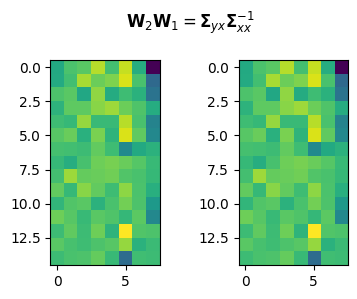

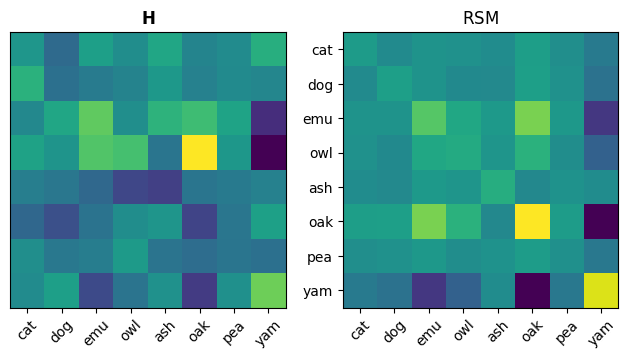

In [24]:
def linear_network(w1, w2, xs):
    return w2 @ w1 @ xs

def mse(y_hat, ys):
    p = ys.shape[1]
    return np.sum((y_hat - ys)**2) / (2.0 * p)

q = np.random.normal(0.0, 1.0, (xs.shape[0], xs.shape[0]))
w1 = q @ np.linalg.pinv(xs @ xs.T)
w2 = ys @ xs.T @ np.linalg.pinv(q)

fig, axs = plt.subplots(1, 2, figsize=(4, 3))
axs[0].imshow(w2 @ w1)
axs[1].imshow(ys @ xs.T @ np.linalg.pinv(xs @ xs.T))
fig.suptitle("$\\mathbf{W}_2\\mathbf{W}_1 = \\mathbf{\\Sigma}_{yx}\\mathbf{\\Sigma}_{xx}^{-1}$")
fig.tight_layout()

print(f"\nThe mean squared error of the network function is {mse(linear_network(w1, w2, xs), ys):.1f}\n")

h = w1 @ xs
rsm = h.T @ h

fig, axs = plt.subplots(1, 2)
ax = axs[0]
ax.imshow(h)
ax.set_title("$\\mathbf{H}$")

ax = axs[1]
ax.imshow(rsm)
ax.set_title("$\\text{RSM}$")

for i in range(2):
    axs[i].set_xticks(range(len(objects)))
    axs[i].set_xticklabels(objects, rotation=45)
axs[0].set_yticks([])
axs[i].set_yticks(range(len(objects)))
axs[i].set_yticklabels(objects)
fig.tight_layout()

As you can see, the network perfectly implements the task, yet, the hidden representation and representational similarity matrix have no similarity with the structure of the task whatsoever! In fact, since the hidden representation and function are dissociable, the hidden representationa and similarity matrix can be almost arbitrary.

Let's play a game, in which we provide you with a hidden representation and similarity matrix, and you have to tell us, if the neural activity patterns come from a network that implements the task or not.

## A special bunch: Minimum-representation norm solutions
So far, we have see, in theory, that function and representation are dissociable. But this raises a natural question: why do do representational similarity matrices often reflect the structure of the task? And why do we ever observe similarites across networks at all?

A key to this puzzle lies in the diversity of solutions within the solution manifold. Some solutions are special - they do not only solve the task but also satisfy additional constraints. In particular, we can focus on minimum-representation norm solution, where both the hidden-layer activations and the readout weights are as small as possible, while still implementing the task. Formally, this corresponds to
$$min_{\mathbf{W}_1, \mathbf{W}_2}||\mathbf{W}_1\mathbf{X}||_F^2 + ||\mathbf{W}_2||_F^2\ \text{such that}\ \mathbf{W}_2\mathbf{W}_1 \mathbf{\Sigma}_{xx} = \mathbf{\Sigma}_{yx}.$$

In fact, one can show that solutions of this form have three important properties:
1. Their representational similarity matrices are stable under changes to hidden activations.
2. Their representational similarity matrices reflect the structure of the task, aligning with intuitive notions of similarity.
3. They are most robust to noise within the network.

Let's find one of these minimum-representation norm solutions and visualize its hidden representations and corresponding representational similarity matrices!

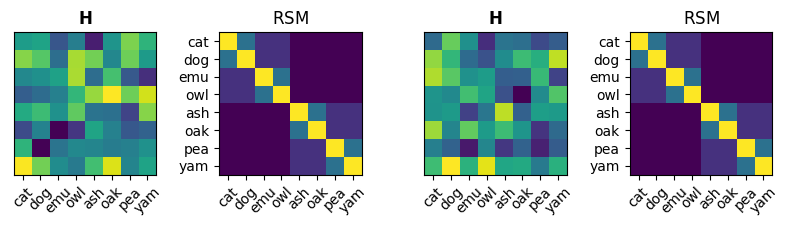

In [43]:
fig, axs = plt.subplots(1, 4, figsize=(8, 4))

for i in range(2):
    r = ortho_group.rvs(8)
    a, b, ct = np.linalg.svd(xs, False)
    m, n, ot = np.linalg.svd(ys @ ct.T @ ct, False)
    
    w1 = r @ np.diag(np.sqrt(n)) @ ot @ np.linalg.pinv(xs)
    w2 = m @ np.diag(np.sqrt(n)) @ r.T

    h = w1 @ xs
    
    axs[i*2].imshow(h)
    axs[(i*2) + 1].imshow(h.T @ h)

for i in range(4):
    axs[i].set_xticks(range(len(objects)))
    axs[i].set_xticklabels(objects, rotation=45)
    if i % 2 == 0:
        axs[i].set_yticks([])
        axs[i].set_title("$\\mathbf{H}$")
    else:
        axs[i].set_yticks(range(len(objects)))
        axs[i].set_yticklabels(objects)
        axs[i].set_title("$\\text{RSM}$")
fig.tight_layout()


As a consequence, representational comparisons become meaningful if and only if two systems not only solve a task but converge to a minimum-representation norm solution. If the regime of the system unknown, their hidden representations and thus their similarity matrices, can be essentially arbitrary and arbirary (dis-)similar, making any comparisons potentially misleading.

## Going beyond linear networks with the teacher-student paradigm

One of the main advantages of the two-layer linear network setting is that we exactly know what is optimal, a privileague that we generally do not have in task-driven non-linear neural networks - because we do not know how to do the math to determine optimality. Fortunately, there does exist a setting in which optimallity is well-defined - the so called teacher-student paradigm. Instead of defining a task via a set of inputs and outputs, we are going to define a _teacher_ neural network as target computation and try to learn this computation in a _student_ neural network.

Under a mild set of assumptions, one can show ...